
#BART ABSTRACTIVE SUMMARIZATION

#Phase 0 : Vocab expansion  (glossary tokens → tokenizer)
#Phase 1 : DAPT             (masked LM on all 670 chunk_text rows)   
#Phase 2 : Fine-tuning      (seq2seq on 381 augmented train pairs)
#Inference: constrained decoding  (Yojana names stay intact)


In [1]:
!pip install transformers datasets rouge-score sentencepiece accelerate bert-score -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00


In [2]:
import os, json, re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from datasets import Dataset, DatasetDict
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    DataCollatorForLanguageModeling,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if device == 'cuda' else 'None'}")

Device : cuda
GPU    : Tesla T4


In [3]:
# ── CELL 3: Config — change only these paths ─────────────────────────────────
CLEANED_CSV      = "indian_budget_dataset_cleaned.csv"       # full cleaned dataset
TRAIN_AUG_CSV    = "train_augmented.csv"         # from EDA/GPT-2 augmentation
VAL_CSV          = "val.csv"
TEST_CSV         = "test.csv"
GLOSSARY_JSON    = "domain_glossary.json"
ACRONYMS_JSON    = "acronyms_abbreviations.json"

BASE_CKPT        = "facebook/bart-base"
VOCAB_DIR        = "./bart-expanded-vocab"       # after Phase 0
DAPT_DIR         = "./bart-dapt/final"           # after Phase 1
FINETUNE_DIR     = "./bart-budget-summarizer"    # after Phase 2

MAX_INPUT_LEN    = 1024
MAX_TARGET_LEN   = 256

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 0 — VOCAB EXPANSION
# Add glossary + acronym terms as atomic tokens so the tokenizer never
# splits "Pradhan Mantri Jan Dhan Yojana" into subword fragments
# ════════════════════════════════════════════════════════════════════════════
# ── CELL 4: Load glossary and expand tokenizer vocab ─────────────────────────

# ── CELL 4: Add individual domain words, not full phrases ────────────────────
with open(GLOSSARY_JSON, encoding="utf-8") as f:
    glossary = json.load(f)

with open(ACRONYMS_JSON, encoding="utf-8") as f:
    acronyms = json.load(f)

tokenizer = BartTokenizer.from_pretrained(BASE_CKPT)

# Extract individual unique words from glossary keys
# e.g. "Pradhan Mantri Jan Dhan Yojana" → ["Pradhan", "Mantri", "Jan", "Dhan", "Yojana"]
domain_words = set()
for term in glossary.keys():
    for word in term.split():
        # Only add words that BART doesn't already tokenize as a single token
        existing_ids = tokenizer.encode(word, add_special_tokens=False)
        if len(existing_ids) > 1:          # currently split into subwords → add it
            domain_words.add(word)

# Acronyms are already single tokens mostly — check and add if not
for acronym in acronyms.keys():
    existing_ids = tokenizer.encode(acronym, add_special_tokens=False)
    if len(existing_ids) > 1:
        domain_words.add(acronym)

new_tokens = sorted(domain_words)
n_added    = tokenizer.add_tokens(new_tokens, special_tokens=False)

print(f"Domain words checked : {len(domain_words)}")
print(f"New tokens added     : {n_added}")
print(f"New vocab size       : {len(tokenizer)}")
print(f"\nTokens added: {new_tokens}")

# Verify
for word in ["Pradhan", "Mantri", "Yojana", "Grameen", "NABARD"]:
    ids = tokenizer.encode(word, add_special_tokens=False)
    print(f"  {word:<20} → {len(ids)} token(s)  {ids}")

os.makedirs(VOCAB_DIR, exist_ok=True)
tokenizer.save_pretrained(VOCAB_DIR)
print(f"\nExpanded tokenizer saved → {VOCAB_DIR}")

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Domain words checked : 183
New tokens added     : 183
New vocab size       : 50448

Tokens added: ['AEO', 'AIDC', 'APA', 'AVGC', 'Abhiyan', 'Anganwadi', 'Antyodaya', 'Atal', 'AtmaNirbhar', 'Aushadhi', 'Awas', 'Ayushman', 'BCD', 'Bamboo', 'Bandhu', 'Bharat', 'Bharatam', 'Bijli', 'Bima', 'CBDT', 'CENVAT', 'CGST', 'CIS', 'CNG', 'CPI', 'CSR', 'CVD', 'DDT', 'DDUGJY', 'DDUGKY', 'DTC', 'Dayal', 'Deen', 'Dhan', 'Divyang', 'Divyangjan', 'EEZ', 'EPF', 'EPFO', 'Ek', 'FCNR', 'FDI', 'FIPB', 'FRBM', 'Fasal', 'GAAR', 'GDP', 'GIFT', 'GST', 'Gandhi', 'Garib', 'Ghar', 'Gram', 'Grameen', 'Gyan', 'HUF', 'Hydrogen', 'IFSC', 'IGST', 'INR', 'ITC', 'ITR', 'Indira', 'Innovation', 'JJM', 'Jal', 'Janjatiya', 'Jawaharlal', 'Jeevan', 'Jyoti', 'KUSUM', 'KYC', 'Kalyan', 'Kaushal', 'Kaushalya', 'Khelo', 'Krishi', 'LCD', 'LPG', 'LiFE', 'Livelihood', 'MACT', 'MRO', 'MSME', 'MSP', 'MUDRA', 'Madhyamik', 'Mantri', 'Matsya', 'Mudra', 'Muft', 'Mukherji', 'NABARD', 'NBFC', 'NCCD', 'NDA', 'NHM', 'NITI', 'NPS', 'NRI', 'NRLM', 

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — DOMAIN ADAPTIVE PRE-TRAINING (DAPT)
# Masked LM on all 670 chunk_text rows (no summaries needed)
# Teaches BART budget vocabulary before it ever sees a summary pair
# ════════════════════════════════════════════════════════════════════════════

# ── CELL 5: Prepare DAPT dataset ─────────────────────────────────────────────
full_df   = pd.read_csv(CLEANED_CSV)
all_texts = full_df["chunk_text"].dropna().astype(str).tolist()
print(f"DAPT corpus : {len(all_texts)} documents")

# Load model and resize embeddings to match expanded vocab
model = BartForConditionalGeneration.from_pretrained(BASE_CKPT)
model.resize_token_embeddings(len(tokenizer))
model = model.to(device)

# Run this right after resize_token_embeddings in Cell 5
with torch.no_grad():
    for token in new_tokens:
        # Get token id of the new token
        new_id = tokenizer.convert_tokens_to_ids(token)

        # Tokenize the same string with the OLD vocab (subword pieces)
        subword_ids = tokenizer.encode(token, add_special_tokens=False)

        # Average the subword embeddings as the starting point
        subword_embeds = model.model.shared.weight[subword_ids]
        model.model.shared.weight[new_id] = subword_embeds.mean(dim=0)

print("New token embeddings initialized from subword averages")

print(f"Embedding table resized to {len(tokenizer)} tokens")

def tokenize_for_dapt(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_INPUT_LEN,
        padding=False,
    )

dapt_ds       = Dataset.from_dict({"text": all_texts})
dapt_tokenized = dapt_ds.map(
    tokenize_for_dapt,
    batched=True,
    remove_columns=["text"],
)

# MLM collator — randomly masks 15% of tokens per batch
dapt_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.10,
)

DAPT corpus : 670 documents


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


New token embeddings initialized from subword averages
Embedding table resized to 50448 tokens


Map:   0%|          | 0/670 [00:00<?, ? examples/s]

In [6]:
# ── CELL 6: DAPT training ────────────────────────────────────────────────────
dapt_args = TrainingArguments(
    output_dir=DAPT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    warmup_ratio=0.2,
    weight_decay=0.01,
    fp16=True,
    logging_steps=20,
    save_strategy="epoch",
    report_to="none",
)

dapt_trainer = Trainer(
    model=model,
    args=dapt_args,
    train_dataset=dapt_tokenized,
    data_collator=dapt_collator,
    processing_class=tokenizer,
)

print("Starting DAPT...")
dapt_trainer.train()

model.save_pretrained(DAPT_DIR)
tokenizer.save_pretrained(DAPT_DIR)
print(f"DAPT complete → saved to {DAPT_DIR}")

# Free memory before Phase 2
del dapt_trainer
torch.cuda.empty_cache()



warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting DAPT...


Step,Training Loss
20,31.867368
40,26.165283
60,23.480180
80,22.126056
100,20.987373
120,20.537114


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DAPT complete → saved to ./bart-dapt/final


In [7]:
# Check what tokens are actually being masked and getting high loss
# Sample one batch manually and see what the hard tokens are

from transformers import DataCollatorForLanguageModeling
import torch

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)

sample     = [dapt_tokenized[i] for i in range(4)]
batch      = collator(sample)
masked_ids = batch["input_ids"]
label_ids  = batch["labels"]       # -100 for unmasked, actual id for masked

# Find which tokens were masked
masked_positions = (label_ids != -100)
masked_token_ids = label_ids[masked_positions].tolist()
masked_tokens    = tokenizer.convert_ids_to_tokens(masked_token_ids)

print(f"Total masked tokens : {len(masked_tokens)}")
print(f"Sample masked tokens: {masked_tokens[:30]}")

# Check if model vocab size matches tokenizer
print(f"\nTokenizer vocab size : {len(tokenizer)}")
print(f"Model embed size     : {model.model.shared.weight.shape[0]}")
print(f"Match?               : {len(tokenizer) == model.model.shared.weight.shape[0]}")

# Check the actual loss on this one batch
model.eval()
with torch.no_grad():
    out = model(
        input_ids=batch["input_ids"].to(device),
        labels=batch["labels"].to(device),
    )
print(f"\nSingle batch loss : {out.loss.item():.4f}")

Total masked tokens : 284
Sample masked tokens: ['ĠIn', 'ised', 'Ġin', 'Ġ2010', 'based', 'c', 'Ġagriculture', 'Ġa', 'Ġrebound', 'Ġrun', 'Ġalso', 'Ġpace', 'Ġdouble', 'Ġnear', 'Ġin', 'Ġfood', 'Ġ20', 'Ġless', 'Ġper', 'Ġstill', ',', 'Ġhigh', 'Ġgovernance', 'Ġremain', 'Ġwould', 'Ġthe', '-', 'Ġsome', 'ĠHowever', 'Ġchallenges']

Tokenizer vocab size : 50448
Model embed size     : 50448
Match?               : True

Single batch loss : 4.7728


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — FINE-TUNING
# Seq2seq summarization on augmented train pairs
# Encoder frozen, label smoothing on, higher LR
# ════════════════════════════════════════════════════════════════════════════

# ── CELL 7: Load splits ───────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_AUG_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Drop is_augmented column if present — not needed for training
for _df in [train_df, val_df, test_df]:
    if "is_augmented" in _df.columns:
        _df.drop(columns=["is_augmented"], inplace=True)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

def to_hf_dataset(df):
    return Dataset.from_dict({
        "input_text" : df["chunk_text"].astype(str).tolist(),
        "target_text": df["summary_text"].astype(str).tolist(),
    })

dataset = DatasetDict({
    "train"     : to_hf_dataset(train_df),
    "validation": to_hf_dataset(val_df),
    "test"      : to_hf_dataset(test_df),
})

Train : 381
Val   : 16
Test  : 16


In [9]:
# ── CELL 8: Load DAPT model + tokenizer ──────────────────────────────────────
tokenizer = BartTokenizer.from_pretrained(DAPT_DIR)
model     = BartForConditionalGeneration.from_pretrained(DAPT_DIR)
model     = model.to(device)

print(f"Loaded DAPT weights from {DAPT_DIR}")
print(f"Vocab size : {len(tokenizer)}")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loaded DAPT weights from ./bart-dapt/final
Vocab size : 50448


In [10]:
# ── CELL 9: Freeze encoder ────────────────────────────────────────────────────
def freeze_encoder(model, freeze_n_layers=6):
    # Freeze shared embeddings
    for param in model.model.shared.parameters():
        param.requires_grad = False
    for param in model.model.encoder.embed_positions.parameters():
        param.requires_grad = False
    # Freeze all encoder layers (bart-base has 6)
    for i, layer in enumerate(model.model.encoder.layers):
        if i < freeze_n_layers:
            for param in layer.parameters():
                param.requires_grad = False

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params     : {total/1e6:.1f}M")
    print(f"Trainable params : {trainable/1e6:.1f}M  ({100*trainable/total:.1f}%)")
    print(f"Frozen params    : {(total-trainable)/1e6:.1f}M")

freeze_encoder(model, freeze_n_layers=6)

Total params     : 139.6M
Trainable params : 57.5M  (41.2%)
Frozen params    : 82.1M


In [11]:
# ── CELL 10: Tokenize ─────────────────────────────────────────────────────────
def preprocess(batch):
    model_inputs = tokenizer(
        batch["input_text"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding=False,
    )
    labels = tokenizer(
        text_target=batch["target_text"],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized = dataset.map(
    preprocess,
    batched=True,
    remove_columns=["input_text", "target_text"],
)
print(tokenized)

Map:   0%|          | 0/381 [00:00<?, ? examples/s]

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 381
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 16
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 16
    })
})


In [12]:
# ── CELL 11: Data collator ────────────────────────────────────────────────────
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)


In [13]:
# ── CELL 12: Metrics ──────────────────────────────────────────────────────────
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if predictions.ndim == 3:
        predictions = np.argmax(predictions, axis=-1)

    vocab_size  = len(tokenizer)
    predictions = np.clip(predictions, 0, vocab_size - 1).astype(np.int32)
    labels      = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels      = np.clip(labels, 0, vocab_size - 1).astype(np.int32)

    decoded_preds, decoded_labels = [], []
    for pred_ids, label_ids in zip(predictions.tolist(), labels.tolist()):
        try:
            decoded_preds.append(tokenizer.decode(pred_ids, skip_special_tokens=True).strip())
        except Exception:
            decoded_preds.append("")
        try:
            decoded_labels.append(tokenizer.decode(label_ids, skip_special_tokens=True).strip())
        except Exception:
            decoded_labels.append("")

    r1 = r2 = rl = 0.0
    for pred, label in zip(decoded_preds, decoded_labels):
        s   = rouge.score(label, pred)
        r1 += s["rouge1"].fmeasure
        r2 += s["rouge2"].fmeasure
        rl += s["rougeL"].fmeasure

    n = len(decoded_preds)

    P, R, F1 = bert_score_fn(
        decoded_preds, decoded_labels,
        lang="en",
        model_type="distilbert-base-uncased",
        device=device,
        verbose=False,
    )

    return {
        "rouge1"      : round(r1 / n, 4),
        "rouge2"      : round(r2 / n, 4),
        "rougeL"      : round(rl / n, 4),
        "bertscore_P" : round(P.mean().item(), 4),
        "bertscore_R" : round(R.mean().item(), 4),
        "bertscore_F1": round(F1.mean().item(), 4),
    }

In [14]:
# ── CELL 13: Training args ────────────────────────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir=FINETUNE_DIR,

    num_train_epochs=10,              # more epochs — encoder is frozen, less risk of overfit
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=3e-4,               # higher LR safe — only decoder trains
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="cosine",

    label_smoothing_factor=0.1,       # softens targets — helps with small data

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,

    fp16=True,
    dataloader_num_workers=2,
    logging_steps=20,
    report_to="none",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bertscore P,Bertscore R,Bertscore F1
1,20.148485,3.854968,0.481100,0.216400,0.312500,0.842300,0.820100,0.830700
2,16.780699,3.709976,0.464600,0.204800,0.305100,0.845700,0.815500,0.829200
3,14.939793,3.611990,0.489300,0.216700,0.326500,0.839100,0.830000,0.833900
4,13.528377,3.678192,0.509900,0.228400,0.326400,0.840800,0.836100,0.838100
5,11.745084,3.677565,0.482000,0.220300,0.308800,0.841300,0.826400,0.832600
6,11.012817,3.713720,0.477100,0.217300,0.321200,0.845400,0.827700,0.835400


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


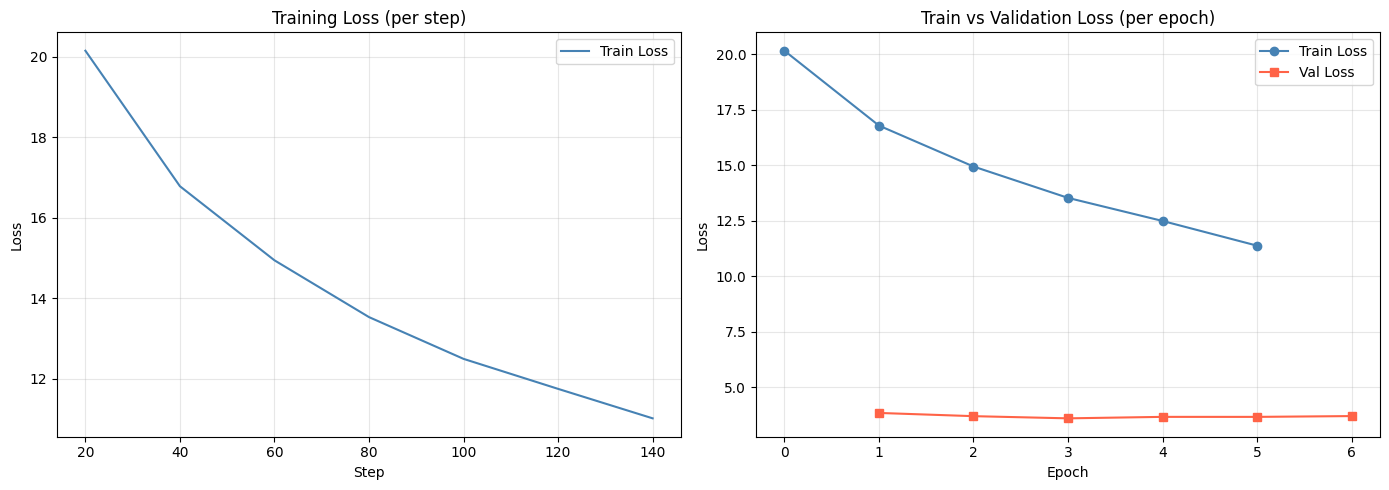

Best val loss  : 3.6120  at epoch 3.0
Final train loss: 11.0128


In [15]:
# ── CELL 14: Trainer + train ──────────────────────────────────────────────────
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Starting fine-tuning...")
trainer.train()

# ── CELL 14b: Plot training and validation loss ───────────────────────────────
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Separate train and eval logs — they have different keys
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_steps  = [x["step"]      for x in train_logs]
train_losses = [x["loss"]      for x in train_logs]
eval_epochs  = [x["epoch"]     for x in eval_logs]
eval_losses  = [x["eval_loss"] for x in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: step-level train loss ───────────────────────────────────────────────
axes[0].plot(train_steps, train_losses, color="steelblue", linewidth=1.5, label="Train Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss (per step)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: epoch-level train vs val loss ──────────────────────────────────────
# Downsample train loss to one point per epoch for fair comparison
train_epoch_logs = [x for x in log_history if "loss" in x and "epoch" in x and "eval_loss" not in x]
epochs_seen      = sorted(set(int(x["epoch"]) for x in train_epoch_logs))
epoch_train_loss = [
    np.mean([x["loss"] for x in train_epoch_logs if int(x["epoch"]) == e])
    for e in epochs_seen
]

axes[1].plot(epochs_seen,  epoch_train_loss, color="steelblue", marker="o", label="Train Loss")
axes[1].plot(eval_epochs,  eval_losses,      color="tomato",    marker="s", label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Train vs Validation Loss (per epoch)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

print(f"Best val loss  : {min(eval_losses):.4f}  at epoch {eval_epochs[eval_losses.index(min(eval_losses))]}")
print(f"Final train loss: {train_losses[-1]:.4f}")

In [16]:
# ── CELL 15: Evaluate on test set ────────────────────────────────────────────
results = trainer.evaluate(tokenized["test"])
print("\nTest Results:")
for k, v in results.items():
    print(f"  {k:<30} {v}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Test Results:
  eval_loss                      3.4560723304748535
  eval_rouge1                    0.5365
  eval_rouge2                    0.2745
  eval_rougeL                    0.3631
  eval_bertscore_P               0.8581
  eval_bertscore_R               0.8371
  eval_bertscore_F1              0.8471
  eval_runtime                   20.2988
  eval_samples_per_second        0.788
  eval_steps_per_second          0.197
  epoch                          6.0


In [23]:
# ── CELL 16: Save final model ─────────────────────────────────────────────────
model.save_pretrained(FINETUNE_DIR + "/final")
tokenizer.save_pretrained(FINETUNE_DIR + "/final")
print(f"Model saved → {FINETUNE_DIR}/final")

# Persist to Google Drive (uncomment):
from google.colab import drive
drive.mount('/content/drive')
!cp -r {FINETUNE_DIR}/final /content/drive/MyDrive/bart-budget-summarizer-dapt

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → ./bart-budget-summarizer/final
Mounted at /content/drive


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# INFERENCE — constrained decoding
# Yojana names and glossary terms are forced to complete correctly
# ════════════════════════════════════════════════════════════════════════════

# ── CELL 17: Build constrained decoding function ─────────────────────────────

# Pre-tokenize every glossary term into token id sequences
glossary_token_seqs = {}
for term in glossary:
    ids = tokenizer.encode(term, add_special_tokens=False)                # only constrain multi-token terms
    glossary_token_seqs[term] = ids

print(f"Constraining {len(glossary_token_seqs)} glossary terms during decoding")

def prefix_allowed_tokens(batch_id, input_ids):
    generated = input_ids.tolist()

    for term, token_seq in glossary_token_seqs.items():
        if len(token_seq) == 1:
            # Single token — nothing to constrain, model either picks it or not
            continue
        for prefix_len in range(1, len(token_seq)):
            if generated[-prefix_len:] == token_seq[:prefix_len]:
                return [token_seq[prefix_len]]

    return list(range(len(tokenizer)))


def summarize(text: str, max_length: int = 400, min_length: int = 80) -> str:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=MAX_INPUT_LEN,
        truncation=True,
    ).to(device)

    summary_ids = model.generate(
        inputs["input_ids"],
        num_beams=4,
        max_length=max_length,
        min_length=min_length,
        length_penalty=3.0,
        early_stopping=False,
        no_repeat_ngram_size=3,
        prefix_allowed_tokens_fn=prefix_allowed_tokens,   # glossary constraint
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

Constraining 74 glossary terms during decoding


In [28]:
# ── CELL 18: Test inference ───────────────────────────────────────────────────
sample_text = val_df.iloc[10]["chunk_text"]
actual      = val_df.iloc[10]["summary_text"]
predicted   = summarize(sample_text)

print(f"INPUT    :\n{sample_text[:400]}\n")
print(f"ACTUAL   :\n{actual}\n")
print(f"PREDICTED:\n{predicted}")

INPUT    :
For collection of bio-mass and distribution of bio-manure, appropriate fiscal support will be provided. 19 Bhartiya Prakritik Kheti Bio-Input Resource Centres . Over the next 3 years, we will facilitate 1 crore farmers to adopt natural farming. For this, 10,000 Bio-Input Resource Centres will be set-up, creating a national-level distributed micro-fertilizer and pesticide manufacturing network. Bui

ACTUAL   :
The government will provide fiscal support for bio-mass collection and bio-manure distribution. Over the next three years, 1 crore farmers will be encouraged to adopt natural farming through 10,000 Bhartiya Prakritik Kheti Bio-Input Resource Centres, creating a national distributed micro-fertilizer and pesticide manufacturing network. The MISHTI initiative will promote mangrove plantations along coastlines and salt pan lands using convergence of MGNREGS, CAMPA Fund, and other sources. Wetlands will be conserved and utilized sustainably through the Amrit Dharohar scheme 

In [29]:
# Run in your Colab — uses YOUR expanded tokenizer
terms = [
    "Pradhan Mantri Jan Dhan Yojana",
    "Pradhan Mantri Gram Sadak Yojana",
    "Indira Awas Yojana",
    "Swachh Bharat Mission",
    "NABARD",
    "GST",
    # also test individual words
    "Pradhan",
    "Mantri",
    "Yojana",
]

print(f"\n{'TERM':<40} {'# TOKENS':<10} TOKENS")
print("─" * 90)
for term in terms:
    ids    = tokenizer.encode(term, add_special_tokens=False)
    tokens = tokenizer.convert_ids_to_tokens(ids)
    print(f"{term:<40} {len(ids):<10} {tokens}")


TERM                                     # TOKENS   TOKENS
──────────────────────────────────────────────────────────────────────────────────────────
Pradhan Mantri Jan Dhan Yojana           1          ['Pradhan Mantri Jan Dhan Yojana']
Pradhan Mantri Gram Sadak Yojana         1          ['Pradhan Mantri Gram Sadak Yojana']
Indira Awas Yojana                       1          ['Indira Awas Yojana']
Swachh Bharat Mission                    1          ['Swachh Bharat Mission']
NABARD                                   1          ['NABARD']
GST                                      1          ['GST']
Pradhan                                  3          ['P', 'rad', 'han']
Mantri                                   3          ['M', 'ant', 'ri']
Yojana                                   3          ['Y', 'oj', 'ana']
